In [71]:
import arviz as az
import matplotlib.pyplot as plt

import numpy as np
from pyro.infer import MCMC, NUTS
import torch
from pyro.infer import Predictive
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
import pandas as pd
import pymc as pm
import pytensor

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn

In [72]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [73]:
def create_data(c_params, n_samples, n_features, n_bias_features):
    features_obs = np.random.uniform(0, 1, size=(n_samples, n_features))
    amount = np.random.uniform(0, 2,size=(n_samples))
    logit_bias = c_params[-1] + np.matmul(features_obs[:, 0:n_bias_features], c_params[0:n_bias_features])
    logit_quant = c_params[n_bias_features]*np.multiply(features_obs[:, n_bias_features], amount) -  c_params[n_bias_features+1]*np.multiply(features_obs[:, n_bias_features + 1], amount ** 2)
    probs_obs = sigmoid(logit_bias + logit_quant)
    y_obs = np.random.binomial(1, probs_obs)
    x_obs = np.hstack((features_obs, amount.reshape(-1, 1)))
    x = torch.from_numpy(x_obs).float()
    y = torch.from_numpy(y_obs).float()

    return x, y, probs_obs


c_params = [ -4,2,3,3,1,-3 ]
n_bias_features = 3
n_features = 5
n_samples_train= 30000
n_samples_val= 2000
n_samples_test= 30000

# train
x_train, y_train, probs_obs_train = create_data(c_params, n_samples_train, n_features, n_bias_features)
x_val, y_val, probs_obs_val = create_data(c_params, n_samples_train, n_features, n_bias_features)
x_test, y_test, probs_obs_test = create_data(c_params, n_samples_test, n_features, n_bias_features)

# test
# x_obs_test = np.random.uniform(0, 1, size=(n_users, num_features))
# probs_obs_test = sigmoid(c_params[0] + np.matmul(x_obs_test, c_params[1:]))
# y_obs_test = np.random.binomial(1, probs_obs_test)



## Model Definition

In [74]:
class Torch_BNN(nn.Module):
    def __init__(self, in_dim, out_dim=1, hid_dim=10):
        super().__init__()
        self.activation = nn.Tanh()  # or nn.ReLU()
        self.layer1 = nn.Linear(in_dim, hid_dim)  # Input to hidden layer
        self.layer2 = nn.Linear(hid_dim, out_dim)  # Hidden to output layer

    def forward(self, x_features, x_actions):
        x = torch.cat((x_features, x_actions))
        x = self.activation(self.layer1(x))
        logits = self.layer2(x).squeeze()
        return logits


In [80]:
def init_network(X,y, hid_dim):

    # Initialize random weights between each layer
    init_w1 = rng.standard_normal(size=(X.shape[1], hid_dim)).astype(floatX)
    init_b1 = rng.standard_normal(size=hid_dim).astype(floatX)

    init_w2 = rng.standard_normal(size=hid_dim).astype(floatX)
    init_b2 = rng.standard_normal(size=1).astype(floatX)

    coords = {
    "hidden_layer": np.arange(hid_dim),
    "train_cols": np.arange(X.shape[1]),
    "out_dim": np.arange(1),
    "obs_id": np.arange(X.shape[0]),
    }
    neural_network = pm.Model(coords=coords)

    with neural_network:

        # Define data variables using minibatches
        ann_input = pm.Data("ann_input", X, mutable=True, dims=("obs_id", "train_cols"))
        ann_output = pm.Data("ann_output", y, mutable=True, dims="obs_id")

        # Weights from input to hidden layer
        weights_in_1 = pm.Normal(
            "w_in_1", 0, sigma=1, initval=init_w1, dims=("train_cols", "hidden_layer")
        )
        bias_1 = pm.Normal(
            "b_1", 0, sigma=1, initval=init_b1, dims=( "hidden_layer")
        )

        # Weights from hidden layer to output
        weights_out = pm.Normal("w_out", 0, sigma=1, initval=init_w2, dims="hidden_layer")
        bias_out = pm.Normal("b_out", 0, sigma=1, initval=init_b2, dims="out_dim")


        # Build neural-network using tanh activation function
        act_1 = pm.math.tanh(pm.math.dot(ann_input, weights_in_1) + bias_1)
        act_out = pm.math.sigmoid(pm.math.dot(act_1, weights_out) + bias_out)

        # Binary classification -> Bernoulli likelihood
        out = pm.Bernoulli(
            "out",
            act_out,
            observed=ann_output,
            total_size=X.shape[0],  # IMPORTANT for minibatches
            dims="obs_id",
        )
    return neural_network





In [104]:
pm.__version__

'5.6.1'

In [87]:
neural_network = init_network(x_train, y_train, 10)

with neural_network:
    approx = pm.fit(n=10_000)

Interrupted at 7,734 [77%]: Average Loss = 22,738


In [102]:
approx.__dict__

{'_scale_cost_to_minibatch': <Scalar(int8, shape=())>,
 'groups': [<pymc.variational.approximations.MeanFieldGroup at 0x7f0031508160>],
 'model': w_in_1 ~ Normal(0, 1)
    b_1 ~ Normal(0, 1)
  w_out ~ Normal(0, 1)
  b_out ~ Normal(0, 1)
    out ~ Unknown(out, 3e+04),
 '_cache': defaultdict(<function pymc.util.locally_cachedmethod.<locals>.self_cache_fn.<locals>.cf.<locals>.<lambda>()>,
             {'datalogp_norm': LRUCache({(HashableWrapper(Approximation{MeanFieldGroup[81]}),): True_div.0}, maxsize=128, currsize=1),
              'datalogp': LRUCache({(HashableWrapper(Approximation{MeanFieldGroup[81]}),): mean}, maxsize=128, currsize=1),
              'sized_symbolic_datalogp': LRUCache({(HashableWrapper(Approximation{MeanFieldGroup[81]}),): Scan{scan_fn, while_loop=False, inplace=none}.1}, maxsize=128, currsize=1),
              '_sized_symbolic_varlogp_and_datalogp': LRUCache({(HashableWrapper(Approximation{MeanFieldGroup[81]}),): (Scan{scan_fn, while_loop=False, inplace=none}.0, S

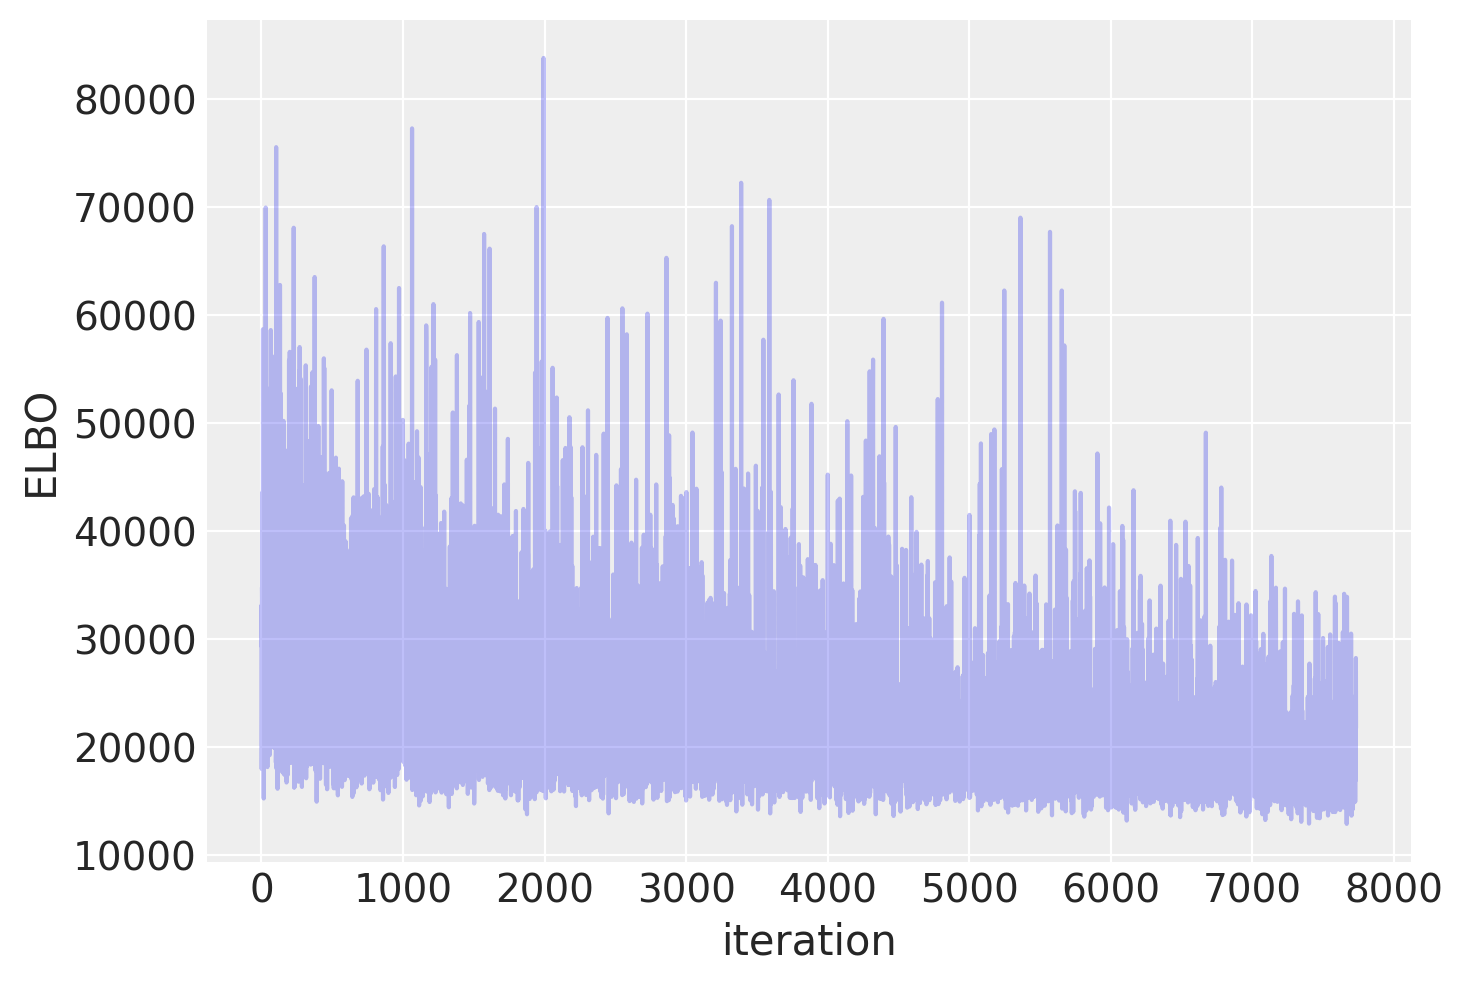

In [90]:
plt.plot(approx.hist, alpha=0.3)
plt.ylabel("ELBO")
plt.xlabel("iteration");

In [45]:
with neural_network:
    pm.set_data(new_data={"ann_input": x_test})
    ppc = pm.sample_posterior_predictive(trace)
    trace.extend(ppc)

Sampling: [out]


In [92]:


approx.shared_params['mu']

mu

In [ ]:
#########

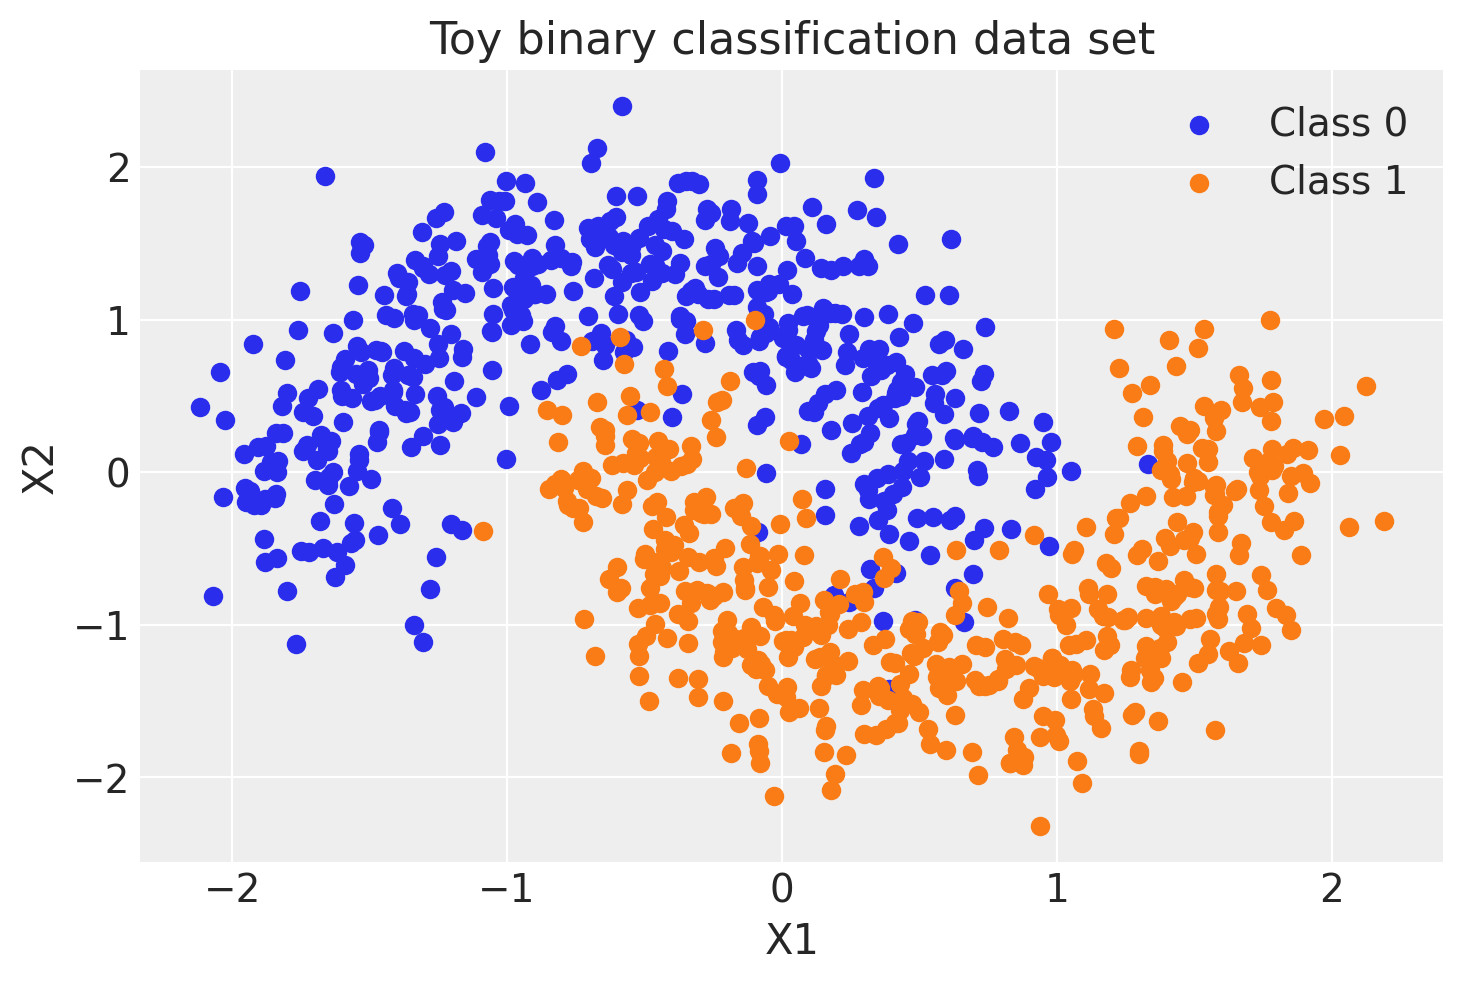

In [13]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
%config InlineBackend.figure_format = 'retina'
floatX = pytensor.config.floatX
RANDOM_SEED = 9927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
X, Y = make_moons(noise=0.2, random_state=0, n_samples=1000)
X = scale(X)
X = X.astype(floatX)
Y = Y.astype(floatX)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5)
fig, ax = plt.subplots()
ax.scatter(X[Y == 0, 0], X[Y == 0, 1], color="C0", label="Class 0")
ax.scatter(X[Y == 1, 0], X[Y == 1, 1], color="C1", label="Class 1")
ax.legend()
ax.set(xlabel="X1", ylabel="X2", title="Toy binary classification data set");

In [69]:
neural_network = init_network(X_train, Y_train, 10)
with neural_network:
    approx = pm.fit(n=20_000)

Finished [100%]: Average Loss = 149.68


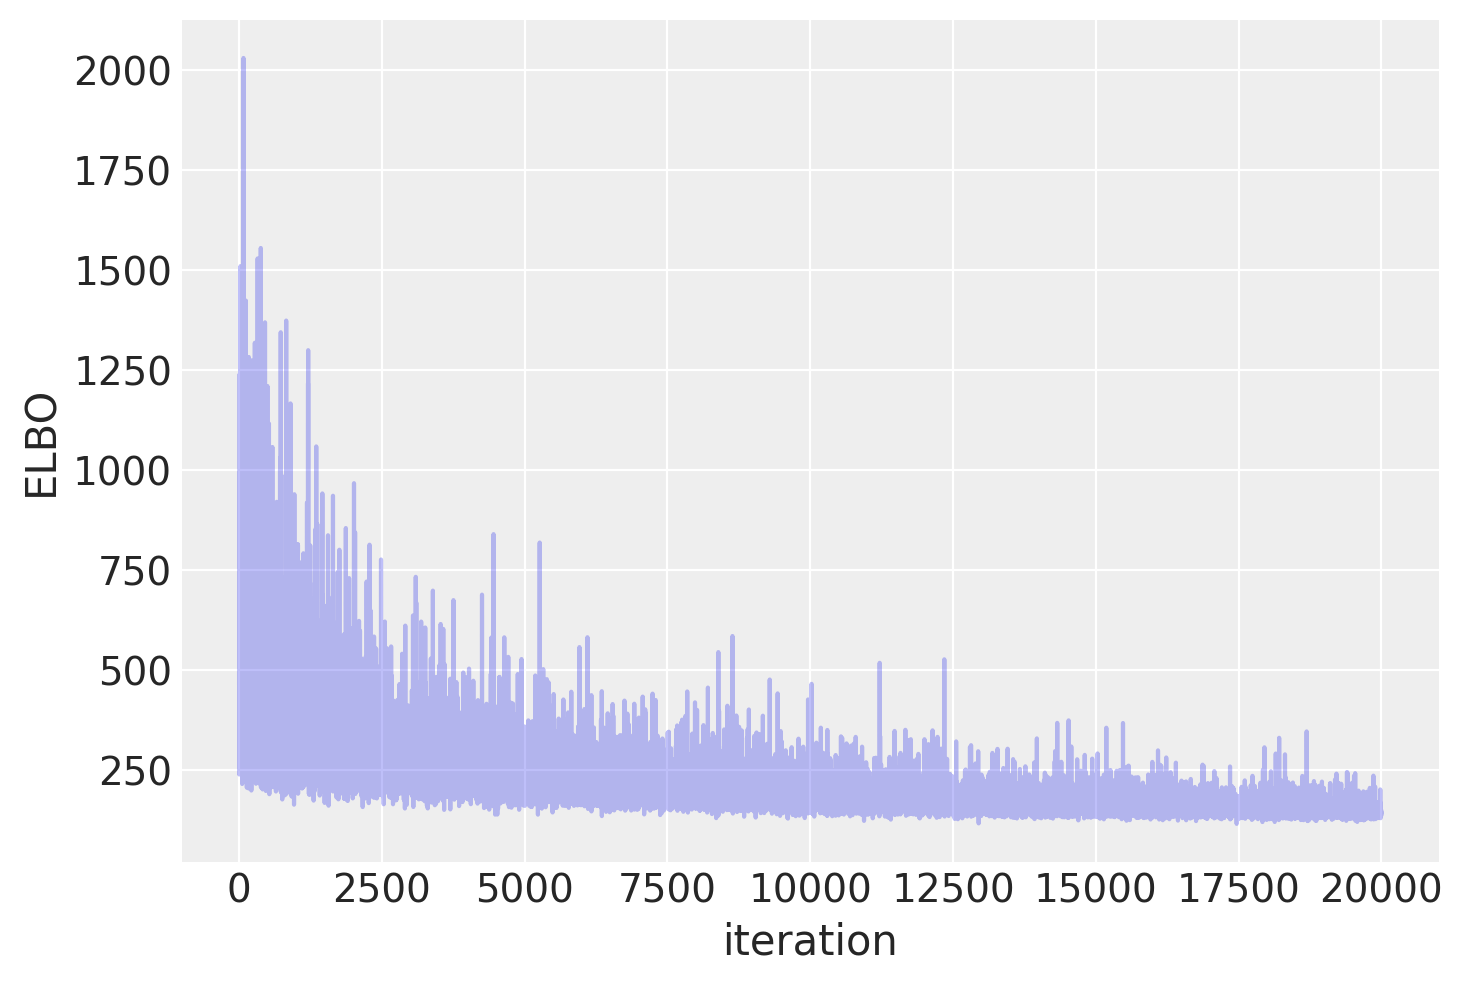

In [70]:
plt.plot(approx.hist, alpha=0.3)
plt.ylabel("ELBO")
plt.xlabel("iteration");

In [43]:
trace = approx.sample(draws=5000)


In [46]:
ppc.posterior_predictive["out"]

<xarray.DataArray 'out' (chain: 1, draw: 5000, obs_id: 500)>
array([[[1, 0, 1, ..., 1, 0, 0],
        [1, 0, 1, ..., 0, 1, 0],
        [0, 0, 1, ..., 1, 1, 0],
        ...,
        [0, 1, 1, ..., 1, 1, 0],
        [1, 0, 0, ..., 1, 1, 1],
        [1, 0, 1, ..., 1, 1, 0]]])
Coordinates:
  * chain    (chain) int64 0
  * draw     (draw) int64 0 1 2 3 4 5 6 7 ... 4993 4994 4995 4996 4997 4998 4999
  * obs_id   (obs_id) int64 0 1 2 3 4 5 6 7 ... 492 493 494 495 496 497 498 499

In [47]:
pred = ppc.posterior_predictive["out"].mean(("chain", "draw")) > 0.5


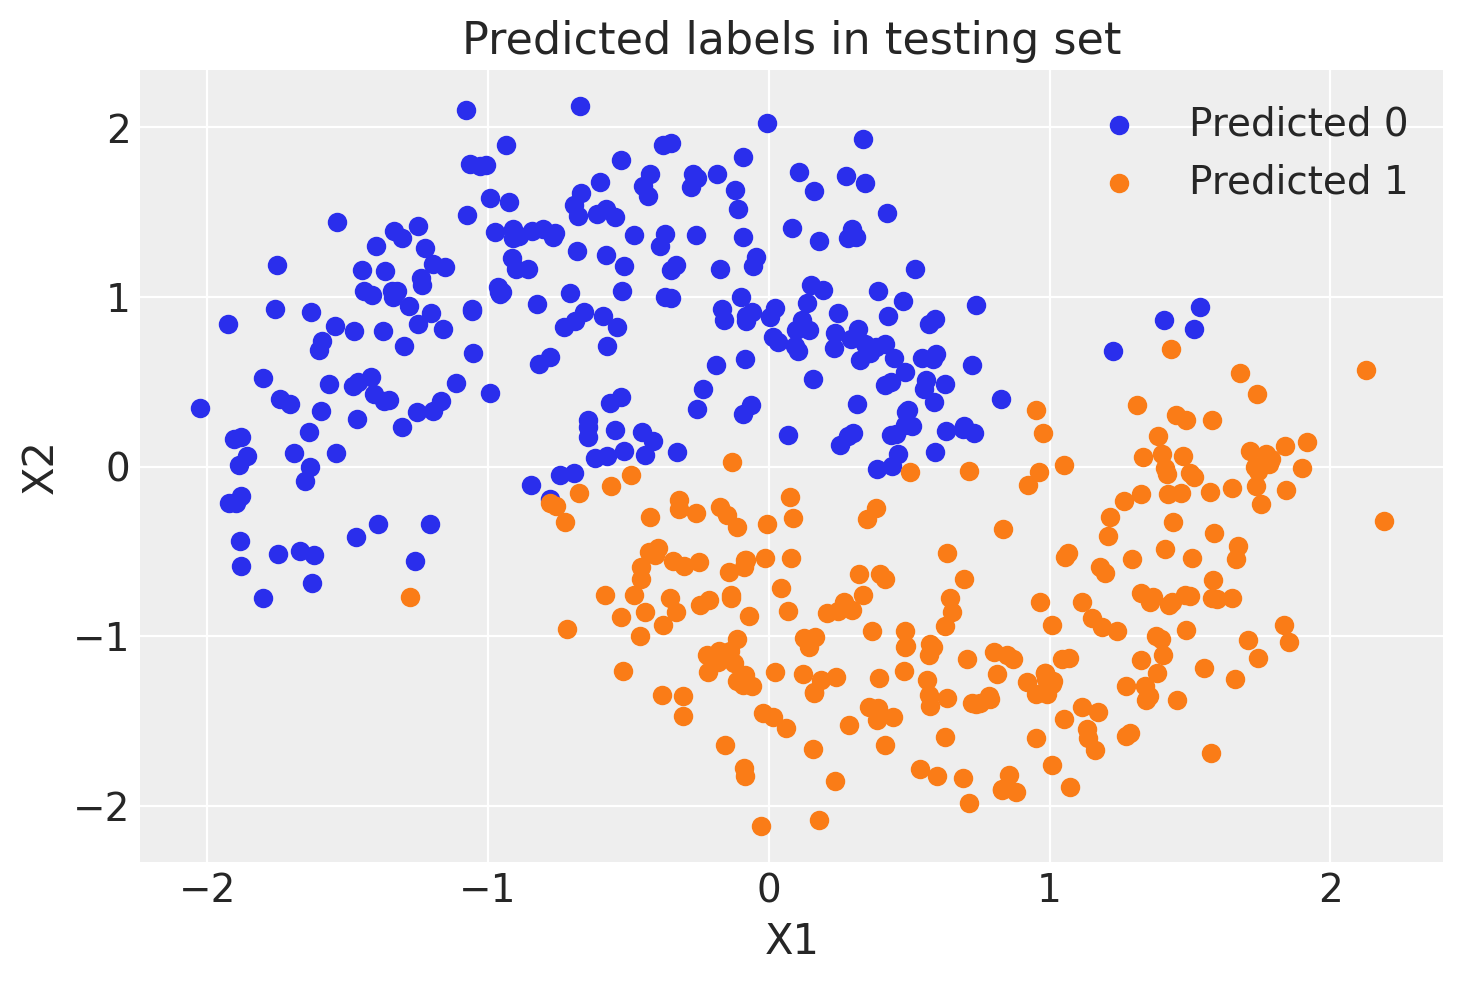

In [48]:
fig, ax = plt.subplots()
ax.scatter(X_test[pred == 0, 0], X_test[pred == 0, 1], color="C0", label="Predicted 0")
ax.scatter(X_test[pred == 1, 0], X_test[pred == 1, 1], color="C1", label="Predicted 1")
ax.legend()
ax.set(title="Predicted labels in testing set", xlabel="X1", ylabel="X2");

In [49]:
print(f"Accuracy = {(Y_test == pred.values).mean() * 100:.2f}%")

Accuracy = 90.60%


## Using pytorch model
